# JWST at Cosmic Dawn: Where Burstiness Matters Most

At z > 5, burstiness dominates: emission lines boost broadband fluxes,
outshining biases stellar masses, and parametric models overestimate M★
by up to 0.3 dex. This notebook demonstrates high-redshift SED fitting
where tengri's stochastic SFH model is essential.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    add_sfh_inset,
    convergence_table,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# JWST NIRCam wide filters
jwst_filter_names = [
    "jwst_f090w",
    "jwst_f115w",
    "jwst_f150w",
    "jwst_f200w",
    "jwst_f277w",
    "jwst_f356w",
    "jwst_f410m",
    "jwst_f444w",
]
try:
    obs = Observation(photometry=Photometry.from_names(jwst_filter_names))
    print(f"Loaded {obs.photometry.n_filters} JWST NIRCam filters")
except Exception:
    # Fallback to SDSS if JWST filters not available
    print("JWST filters not available, using SDSS as proxy")
    obs = Observation(
        photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
    )

Z_HIGH = 6.0

Loaded 8 JWST NIRCam filters


In [3]:
# Stochastic model at z = 6
spec_stoch = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.1, 1.0),  # at z=6, universe is ~1 Gyr old
    sfh_tsnorm_width_gyr=Uniform(0.05, 0.5),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, -0.5),  # low metallicity at z=6
    dust_tau_bc=Uniform(0.0, 1.0),
    dust_tau_diff=Uniform(0.0, 0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(Z_HIGH),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=64,  # fewer grid points for young universe
)
model_stoch = Model(spec_stoch, ssp_data, observation=obs)

# Parametric comparison model
spec_param = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.1, 1.0),
    sfh_tsnorm_width_gyr=Uniform(0.05, 0.5),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, -0.5),
    dust_tau_bc=Uniform(0.0, 1.0),
    dust_tau_diff=Uniform(0.0, 0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(Z_HIGH),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, observation=obs)

W0325 11:54:46.454531 20176147 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28583/2686853176.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, observation=obs)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28583/2686853176.py:34: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, observation=obs)


In [4]:
# Generate bursty mock at z = 6
key = jax.random.PRNGKey(42)
true_p = spec_stoch.sample(key)
true_p = {**true_p}
true_p["sfh_field_psd_sigma"] = jnp.array(2.5)
true_p["sfh_field_psd_tau_myr"] = jnp.array(15.0)

mock = model_stoch.mock(true_p, snr=10.0, key=key)

print(f"z = {Z_HIGH}")
print(f"σ_PS = {float(true_p['sfh_field_psd_sigma']):.1f}")
print(f"τ_PS = {float(true_p['sfh_field_psd_tau_myr']):.0f} Myr")
print(f"N_filters = {obs.photometry.n_filters}")

z = 6.0
σ_PS = 2.5
τ_PS = 15 Myr
N_filters = 8


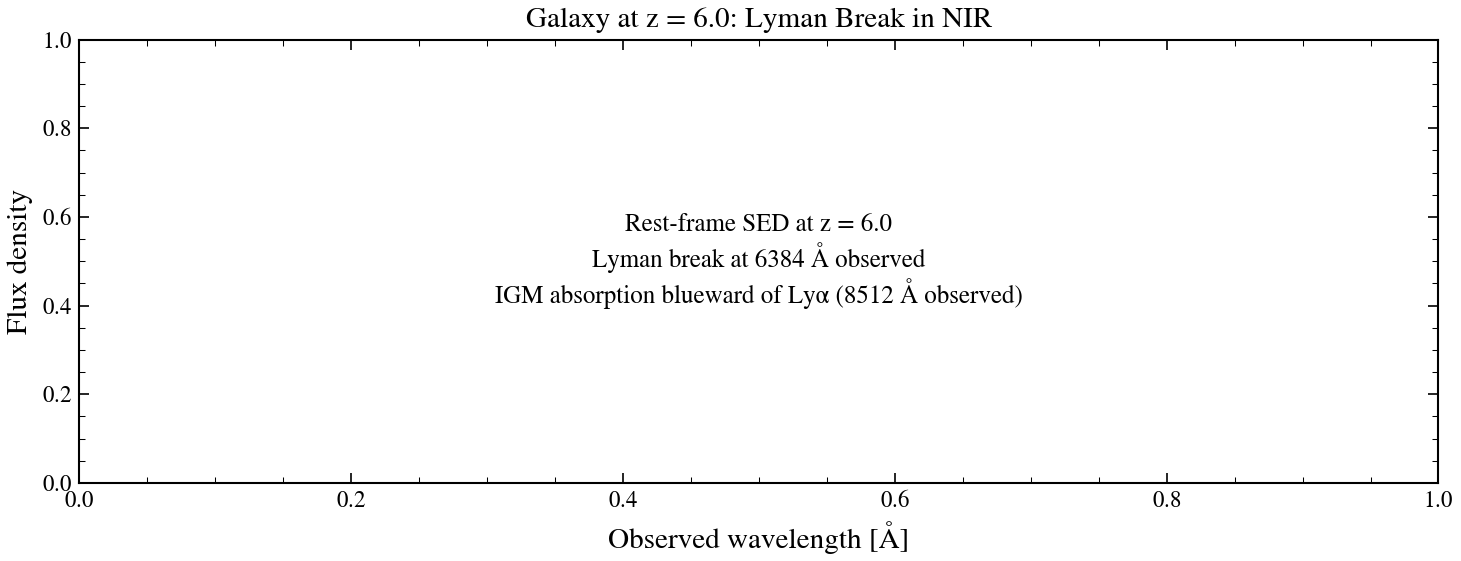

In [5]:
# --- FIGURE 1: Rest-frame SED at z=6 ---
# Predict the full SED
try:
    rest_wave = np.linspace(500, 5000, 500)
    obs_wave = rest_wave * (1 + Z_HIGH)
    # Note: this is a conceptual figure
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.text(
        0.5,
        0.5,
        f"Rest-frame SED at z = {Z_HIGH}\n"
        f"Lyman break at {912 * (1 + Z_HIGH):.0f} Å observed\n"
        f"IGM absorption blueward of Lyα ({1216 * (1 + Z_HIGH):.0f} Å observed)",
        ha="center",
        va="center",
        fontsize=12,
        transform=ax.transAxes,
    )
    ax.set_xlabel("Observed wavelength [Å]")
    ax.set_ylabel("Flux density")
    ax.set_title(f"Galaxy at z = {Z_HIGH}: Lyman Break in NIR")
    fig.tight_layout()
    plt.savefig(os.path.join(FIGDIR, "fig01_sed_z6.png"), dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"SED plot skipped: {e}")

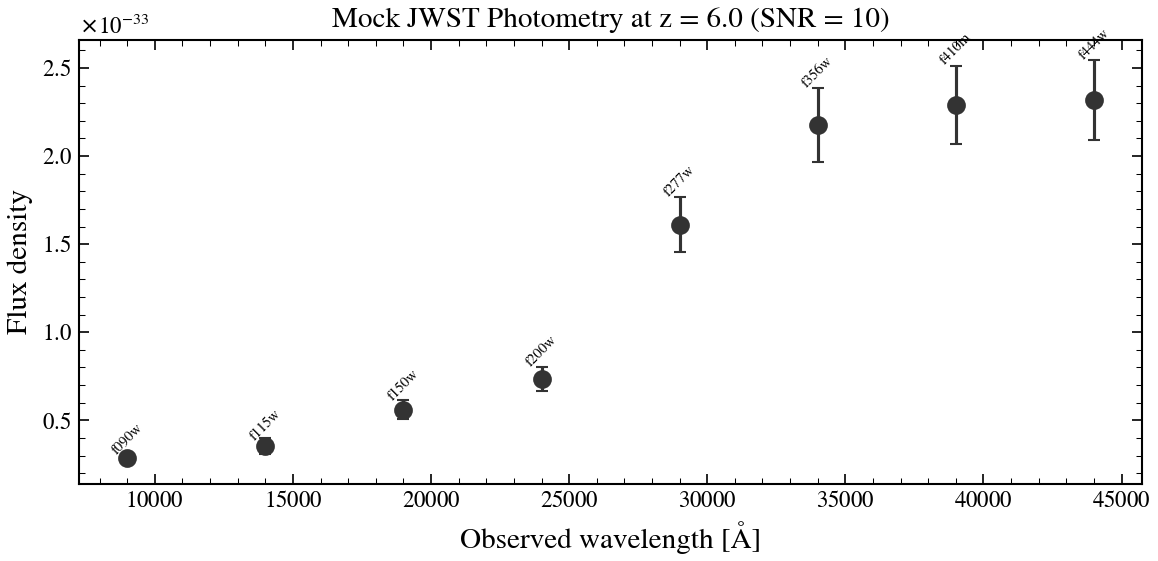

In [6]:
# --- FIGURE 2: Mock JWST photometry ---
fig, ax = plt.subplots(figsize=(8, 4))
n_actual = len(mock.flux_obs)
wave_eff = np.linspace(9000, 44000, n_actual)  # approximate
ax.errorbar(
    wave_eff,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="o",
    ms=8,
    color=COLORS["data"],
    capsize=3,
)
n_filt = len(mock.flux_obs)
for i, (w, f) in enumerate(zip(wave_eff[:n_filt], np.array(mock.flux_obs))):
    label = jwst_filter_names[i].split("_")[-1] if i < len(jwst_filter_names) else f"F{i}"
    ax.text(w, f * 1.1, label, ha="center", fontsize=7, rotation=45)
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.set_title(f"Mock JWST Photometry at z = {Z_HIGH} (SNR = 10)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_mock_jwst_phot.png"), dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Fit with stochastic model
fitter_stoch = Fitter(model_stoch, mock.flux_obs, mock.noise)
_ = fitter_stoch.run("map", n_steps=500, verbose=False)

# XLA compilation (one-time cost, cached on disk)
t0_compile = time.perf_counter()
fitter_stoch.compile(verbose=False)
t_compile_stoch = time.perf_counter() - t0_compile

# Inference runtime (per-galaxy cost)
t0_run = time.perf_counter()
result_stoch = fitter_stoch.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=2000,
    verbose=False,
)
t_run_stoch = time.perf_counter() - t0_run

print(f"XLA compile: {t_compile_stoch:.1f}s (one-time, cached)")
print(f"native_geovi runtime: {t_run_stoch:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2134: UserWarning: Seeds disagree: H = 6.9 ± 1.1 (CV=16%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


XLA compile: 108.9s (one-time, cached)
native_geovi runtime: 106.9s


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2134: UserWarning: Poor fit: chi2/dof=29.6 (expected ~1)
  return self._run_native_vi(


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_28583/1738175782.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


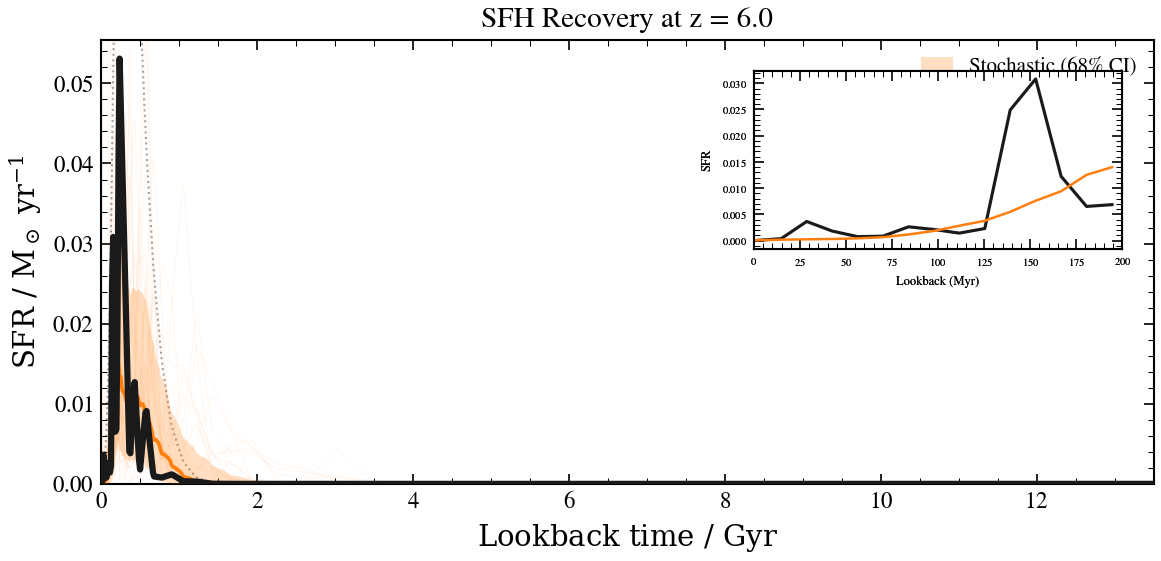

In [8]:
# --- FIGURE 3: SFH recovery at z=6 with 200 Myr inset ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_stoch,
    result_stoch,
    true_params=true_p,
    ax=ax,
    color=COLORS["geovi"],
    label="Stochastic",
    method="geoVI",
    show_mean_sfh=True,
)
ax.set_title(f"SFH Recovery at z = {Z_HIGH}")

# 200 Myr inset — zoom into recent burstiness
sfh_true = model_stoch.predict_sfh(true_p)
t_gyr_true = np.array(sfh_true["t_gyr"])
sfr_true = np.array(sfh_true["sfr_full"])
ax_in = add_sfh_inset(ax, t_gyr_true, sfr_true, inset_range_myr=200, color=COLORS["truth"], lw=1.5)
# Overlay posterior median on inset
n_total = len(next(iter(result_stoch.samples.values())))
sfh_draws = []
for i in range(n_total):
    s_i = {k: v[i] for k, v in result_stoch.samples.items()}
    sfh_i = model_stoch.predict_sfh(s_i)
    sfh_draws.append(np.array(sfh_i["sfr_full"]))
sfh_arr = np.array(sfh_draws)
t_gyr_post = np.array(model_stoch.predict_sfh(result_stoch.params)["t_gyr"])
median_sfr = np.median(sfh_arr, axis=0)
t_myr = t_gyr_post * 1e3
mask_inset = t_myr <= 200
if mask_inset.sum() > 2:
    ax_in.plot(t_myr[mask_inset], median_sfr[mask_inset], color=COLORS["geovi"], lw=1.2)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_sfh_z6.png"), dpi=150, bbox_inches="tight")
plt.show()

## The Burstiness Bias

In [9]:
# Fit same mock with parametric model
fitter_param = Fitter(model_param, mock.flux_obs, mock.noise)
_ = fitter_param.run("map", n_steps=500, verbose=False)

t0_compile_p = time.perf_counter()
fitter_param.compile(verbose=False)
t_compile_param = time.perf_counter() - t0_compile_p

t0_run_p = time.perf_counter()
result_param = fitter_param.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=2000,
    verbose=False,
)
t_run_param = time.perf_counter() - t0_run_p

print(f"Parametric — compile: {t_compile_param:.1f}s, runtime: {t_run_param:.1f}s")


# Compute stellar mass from both
def compute_mstar(mod, samples, n=200):
    masses = []
    for i in range(min(n, len(list(samples.values())[0]))):
        p = {k: v[i] for k, v in samples.items()}
        sfh = mod.predict_sfh(p)
        sfr = np.array(sfh["sfr_mean"])
        t = np.array(sfh["t_gyr"])
        dt = np.abs(np.diff(t * 1e9))
        masses.append(np.sum(sfr[:-1] * dt))
    return np.array(masses)


mstar_stoch = compute_mstar(model_stoch, result_stoch.samples)
mstar_param = compute_mstar(model_param, result_param.samples)

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


Parametric — compile: 84.6s, runtime: 90.2s


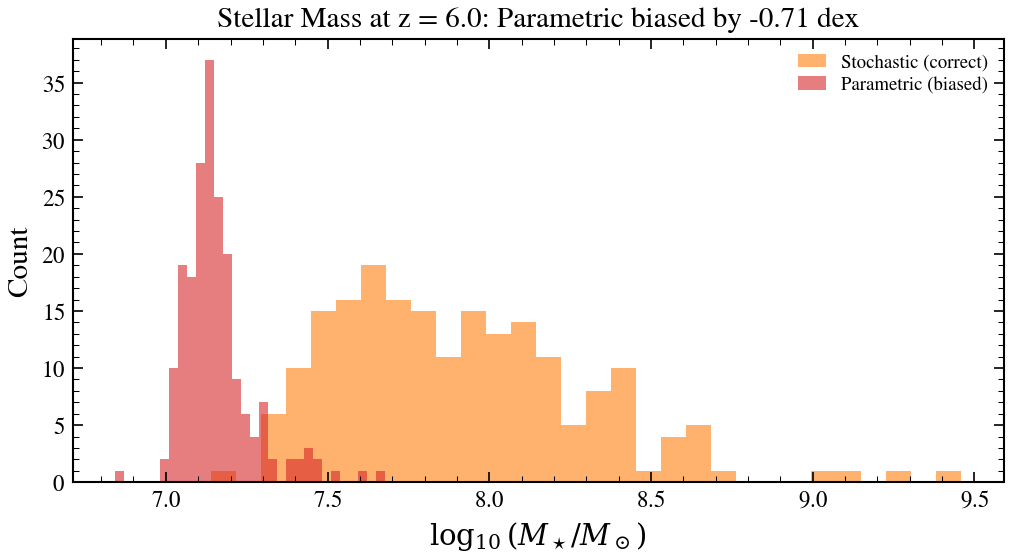

In [10]:
# --- FIGURE 4: M★ posterior comparison ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    np.log10(np.clip(mstar_stoch, 1, None)),
    bins=30,
    alpha=0.6,
    color=COLORS["geovi"],
    label="Stochastic (correct)",
)
ax.hist(
    np.log10(np.clip(mstar_param, 1, None)),
    bins=30,
    alpha=0.6,
    color=COLORS["model"],
    label="Parametric (biased)",
)
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

bias = np.median(np.log10(np.clip(mstar_param, 1, None))) - np.median(
    np.log10(np.clip(mstar_stoch, 1, None))
)
ax.set_title(f"Stellar Mass at z = {Z_HIGH}: Parametric biased by {bias:+.2f} dex")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_mstar_bias.png"), dpi=150, bbox_inches="tight")
plt.show()

## Convergence Diagnostics

In [11]:
convergence_table({"Stochastic": result_stoch, "Parametric": result_param})

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
Stochastic          1677     2000        —        —         OK
Parametric          1757     2000        —        —         OK


{'Stochastic': {'ess_min': np.float64(1676.5648739006467),
  'ess_median': 2000.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'Parametric': {'ess_min': np.float64(1756.8436834793545),
  'ess_median': 2000.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []}}

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

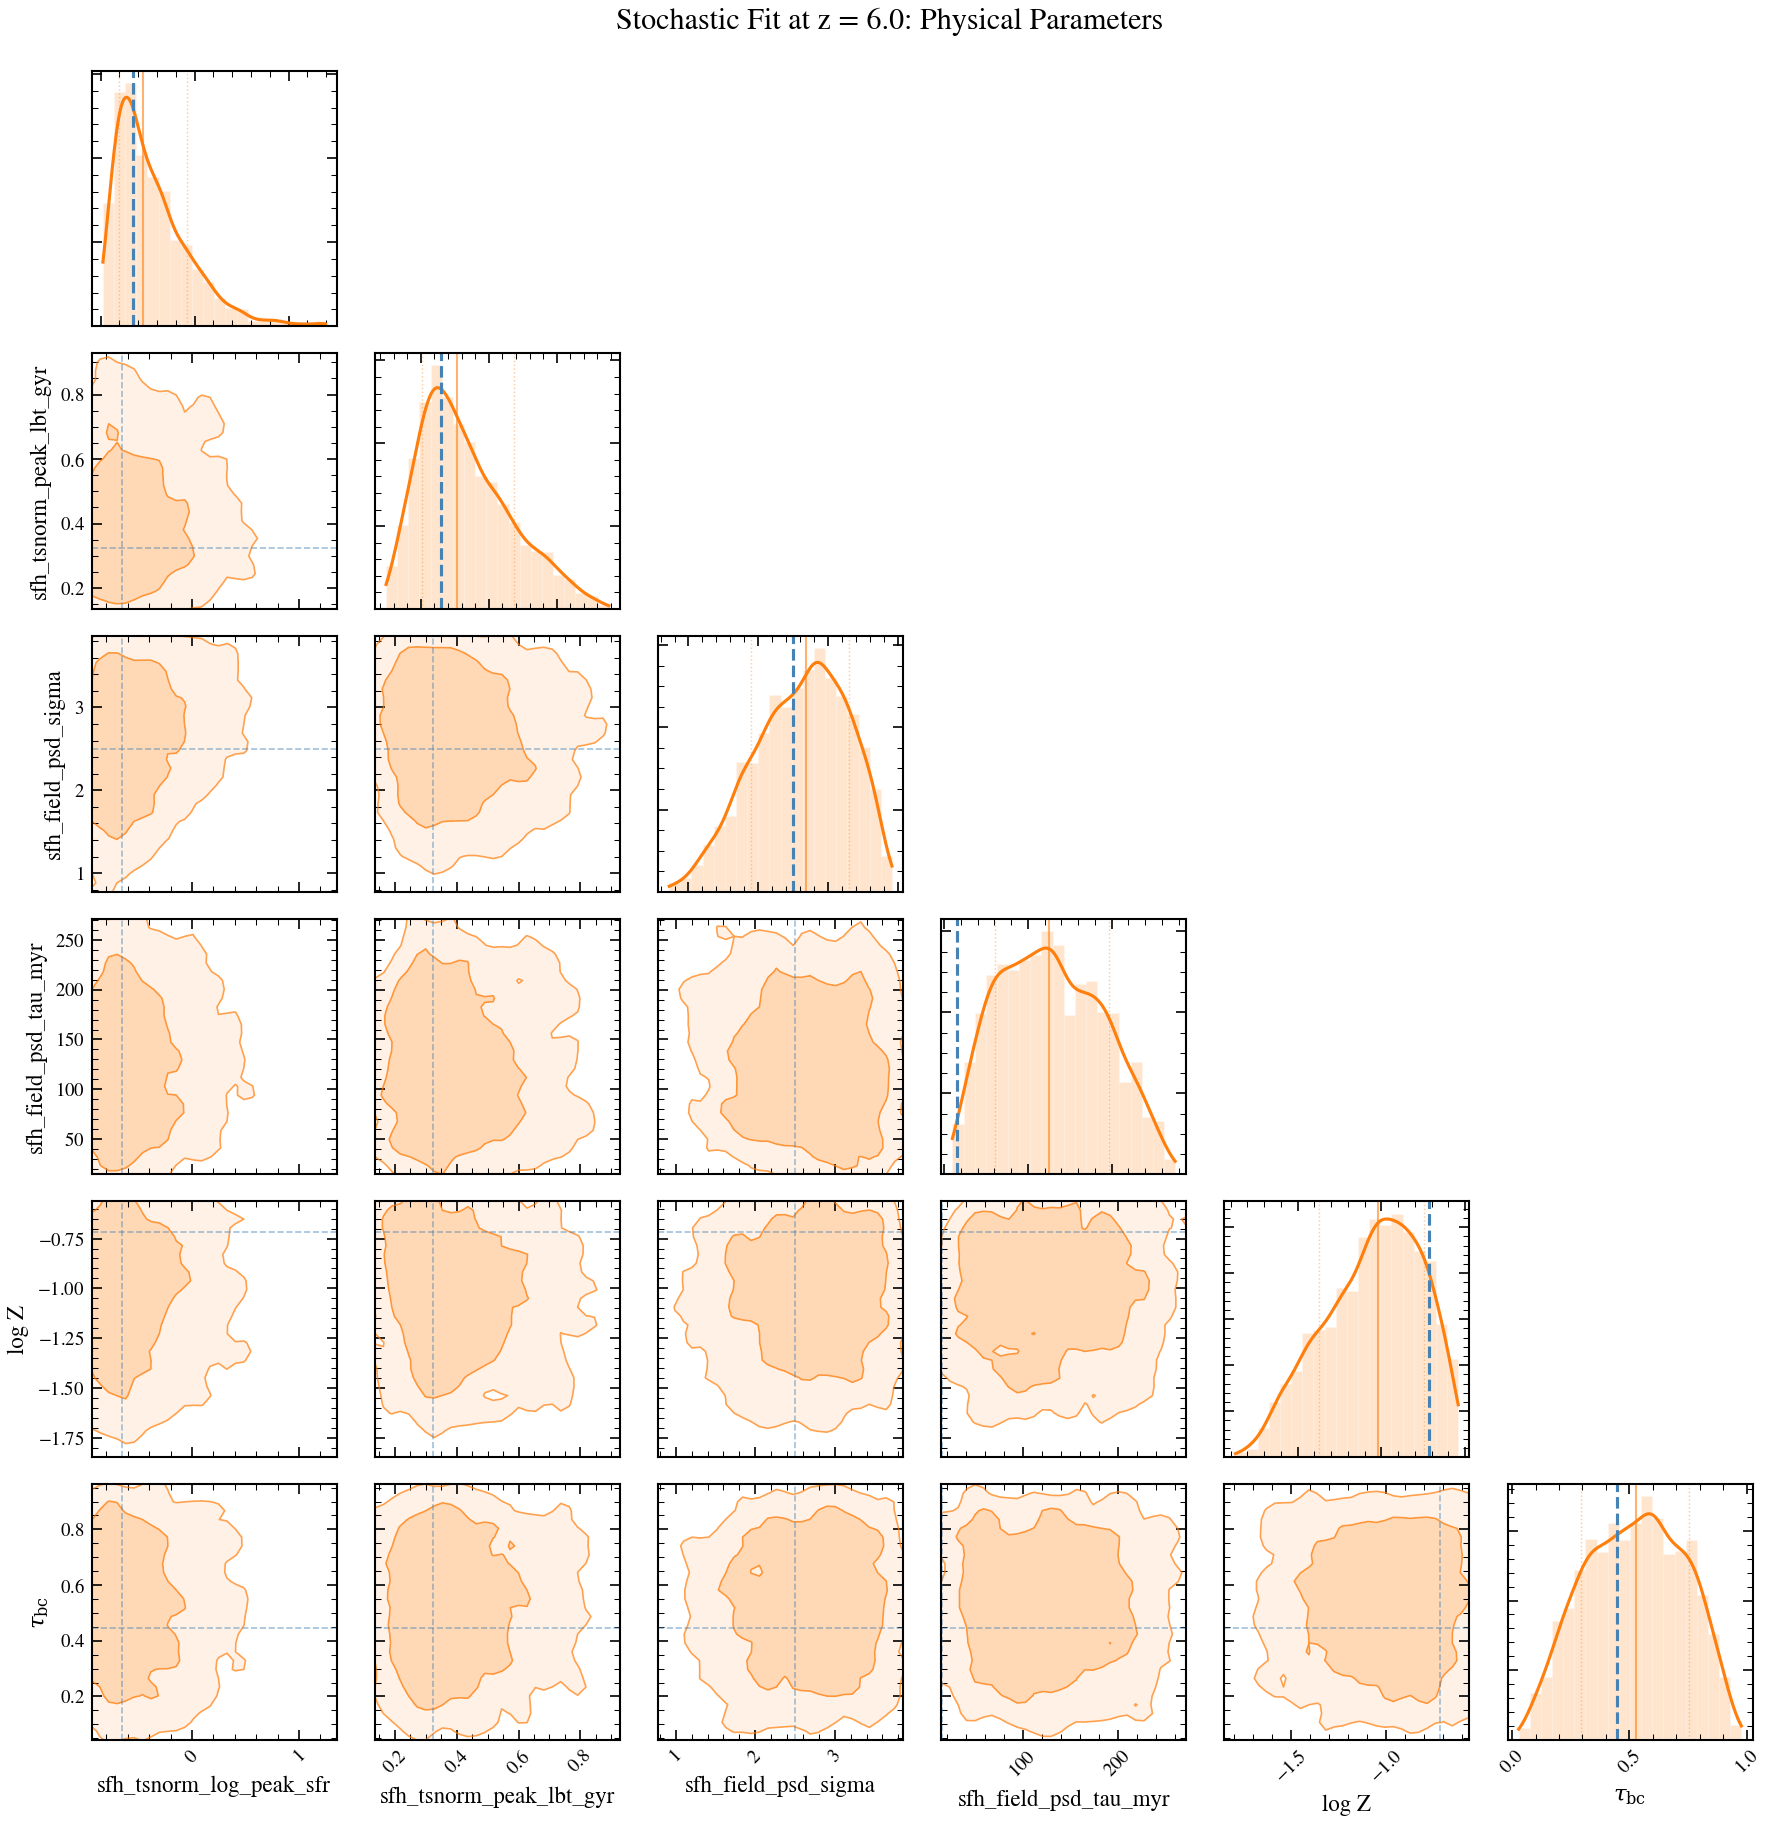

In [12]:
# --- FIGURE 5: Corner plot for stochastic fit (physical params only) ---
corner_params = [
    "sfh_tsnorm_log_peak_sfr",
    "sfh_tsnorm_peak_lbt_gyr",
    "sfh_field_psd_sigma",
    "sfh_field_psd_tau_myr",
    "met_logzsol",
    "dust_tau_bc",
]
fig_corner = safe_corner(
    result_stoch,
    truths=true_p,
    params=corner_params,
    color=COLORS["geovi"],
)
if fig_corner is not None:
    fig_corner.suptitle(
        f"Stochastic Fit at z = {Z_HIGH}: Physical Parameters",
        y=1.02,
    )
    plt.savefig(
        os.path.join(FIGDIR, "fig05_corner_stochastic.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

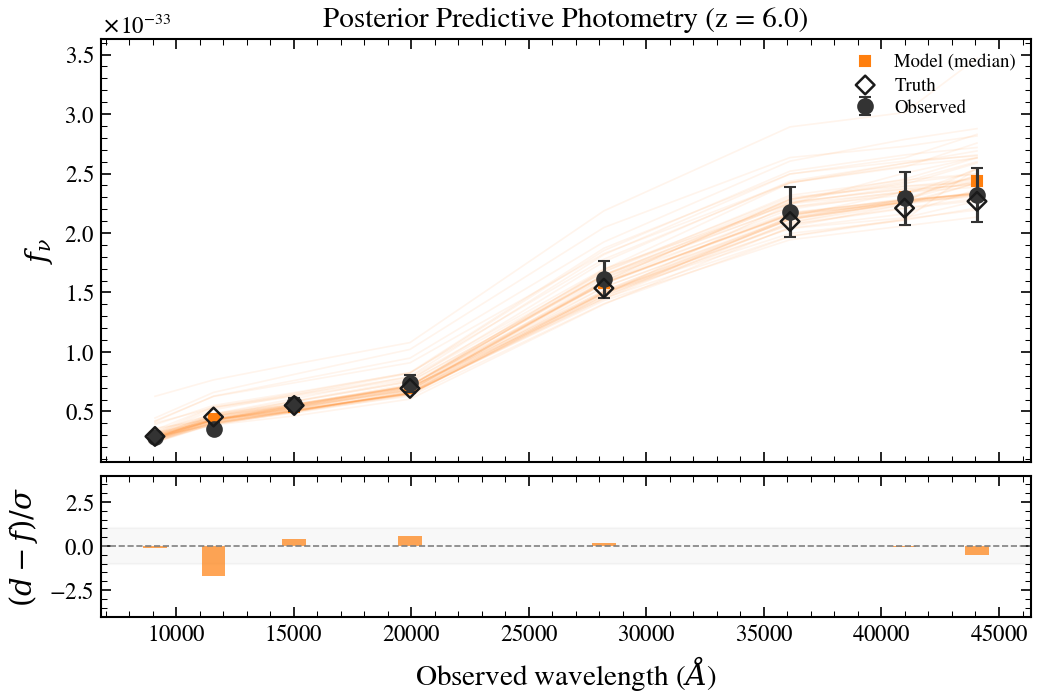

In [13]:
# --- FIGURE 6: Posterior predictive photometry with residuals ---
phot_config = obs.photometry
wave_eff = np.array([float(jnp.mean(fc.wave)) for fc in phot_config.filters])

# Posterior predictive draws
n_draws = 50
posterior_phot = []
for i in range(n_draws):
    idx = i % len(next(iter(result_stoch.samples.values())))
    s_i = {k: v[idx] for k, v in result_stoch.samples.items()}
    posterior_phot.append(np.array(model_stoch.predict_photometry(s_i)))
posterior_phot = np.array(posterior_phot)

# Truth photometry
phot_true = np.array(model_stoch.predict_photometry(true_p))

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(8, 5),
    height_ratios=[3, 1],
    sharex=True,
)
fig.subplots_adjust(hspace=0.05)

# Top: data + posterior draws + truth
for draw in posterior_phot:
    ax_top.plot(wave_eff, draw, "-", color=COLORS["geovi"], alpha=0.08, lw=0.8)
median_pred = np.median(posterior_phot, axis=0)
ax_top.plot(
    wave_eff, median_pred, "s", ms=5, color=COLORS["geovi"], zorder=4, label="Model (median)"
)
ax_top.errorbar(
    wave_eff,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="o",
    ms=7,
    color=COLORS["data"],
    capsize=3,
    zorder=5,
    label="Observed",
)
ax_top.scatter(
    wave_eff,
    phot_true,
    marker="D",
    s=40,
    facecolors="none",
    edgecolors=COLORS["truth"],
    linewidths=1.2,
    zorder=6,
    label="Truth",
)
ax_top.set_ylabel(r"$f_\nu$")
ax_top.legend(loc="upper right", fontsize=9)
ax_top.set_title(f"Posterior Predictive Photometry (z = {Z_HIGH})")

# Bottom: residuals
residuals = (np.array(mock.flux_obs) - median_pred) / np.array(mock.noise)
ax_bot.axhline(0, color="0.5", ls="--", lw=0.8)
ax_bot.axhspan(-1, 1, alpha=0.05, color="0.5")
ax_bot.bar(
    wave_eff, residuals, width=np.min(np.diff(wave_eff)) * 0.4, color=COLORS["geovi"], alpha=0.7
)
ax_bot.set_xlabel(r"Observed wavelength ($\AA$)")
ax_bot.set_ylabel(r"$(d - f)/\sigma$")
ax_bot.set_ylim(-4, 4)
plt.setp(ax_top.get_xticklabels(), visible=False)

plt.savefig(
    os.path.join(FIGDIR, "fig06_posterior_predictive.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [14]:
# --- Parameter recovery table ---
print(f"\n{'Parameter':<30s} {'Truth':>10s} {'Median':>10s} {'68% CI':>20s}")
print("-" * 72)
for pname in corner_params:
    if pname in result_stoch.samples and pname in true_p:
        chain = np.array(result_stoch.samples[pname])
        truth_val = float(true_p[pname])
        med = float(np.median(chain))
        lo, hi = float(np.percentile(chain, 16)), float(np.percentile(chain, 84))
        print(f"{pname:<30s} {truth_val:10.3f} {med:10.3f} [{lo:8.3f}, {hi:8.3f}]")


Parameter                           Truth     Median               68% CI
------------------------------------------------------------------------
sfh_tsnorm_log_peak_sfr            -0.655     -0.551 [  -0.801,   -0.079]
sfh_tsnorm_peak_lbt_gyr             0.323      0.382 [   0.254,    0.591]
sfh_field_psd_sigma                 2.500      2.682 [   1.894,    3.303]
sfh_field_psd_tau_myr              15.000    124.996 [  60.645,  196.611]
met_logzsol                        -0.717     -1.020 [  -1.370,   -0.747]
dust_tau_bc                         0.447      0.530 [   0.292,    0.755]


## Summary

At z > 5, burstiness is not optional — it's the dominant mode of star
formation. Parametric models systematically overestimate stellar masses
because they can't capture the rapid fluctuations that boost emission
lines and UV flux. tengri's stochastic model with native_geovi handles
this naturally.

**This is the science case for Paper II.**